### 📦 Install Dependencies
This cell installs required libraries.

In [ ]:
!pip install openai networkx matplotlib

### 📚 Import Libraries
Load all required Python modules.

In [ ]:
import os
import re
import ast
import networkx as nx
import matplotlib.pyplot as plt

### 🔑 Add OpenAI API Key
Replace with your own key.

In [ ]:
from openai import OpenAI
client = OpenAI(api_key = "YOUR_API_KEY")
MODEL = "gpt-4o-mini"

### 🧠 Helper — Extract Triplets from Ticket
Define a function that converts raw ticket text into a Python list of (subject, relation, object) triplets.


In [ ]:
ONTOLOGY_PROMPT = prompt = f"""
Extract entities and relationships from the following text and output them
AS A PYTHON LIST OF TRIPLETS.

Your output MUST follow this exact format:
[
  ("Entity1", "relationship_label", "Entity2"),
  ("EntityA", "relationship_label", "EntityB")
]

======================================================
ONTOLOGY (USE THIS STRUCTURE EXACTLY)
======================================================

ENTITY TYPES:
- Customer: A person or account reporting an issue.
- Issue: A problem, malfunction, or negative experience.
- Product: A device, service, or component affected by the issue.
- Cause: A root cause, update, action, or event that triggers the issue.
- Resolution: A fix, patch, workaround, or step that resolves the issue.

RELATIONSHIP TYPES (snake_case only):
- reports: Customer → Issue
- affects: Issue → Product
- caused_by: Issue → Cause
- resolved_by: Issue → Resolution

SCHEMA RULES:
1. All entity names must be **descriptive and capitalized**
   (e.g., Customer 4759, Overheating Issue, Latest Update, Patch 1.2).
2. All relationships must use the ontology labels above.
3. If the text implies a support ticket, infer:
     Customer → reports → Issue
4. Extract **all meaningful triplets**, not just one.
5. Do NOT include explanations — output ONLY the Python list.

======================================================
"""

def extract_triplets(ticket_text: str) -> list[tuple[str, str, str]]:
    prompt = f"{ONTOLOGY_PROMPT}\n\nText:\n{ticket_text}\n"
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    raw = resp.choices[0].message.content.strip()

    # Safe parse: expects Python list of tuples
    try:
        triplets = ast.literal_eval(raw)
        if isinstance(triplets, list):
            return [tuple(t) for t in triplets]
    except Exception:
        pass

    # Fallback: parse tuple lines if format is noisy
    out = []
    for line in raw.splitlines():
        line = line.strip().rstrip(",")
        if line.startswith("(") and line.endswith(")"):
            try:
                out.append(ast.literal_eval(line))
            except Exception:
                continue
    return out


### 🔧 Helper — Add Triplets to Graph
Create nodes and edges from extracted triplets.


In [ ]:
def add_triplets(G: nx.DiGraph, triplets: list[tuple[str, str, str]], edge_attr: str = "label"):
    for s, r, o in triplets:
        G.add_node(s)
        G.add_node(o)
        G.add_edge(s, o, **{edge_attr: r})


### 🎨 Helper — Draw Graph
Render the graph so we can visually spot duplicates and structure changes.


In [ ]:
def draw_graph(G: nx.DiGraph, title: str):
    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=7)
    nx.draw(G, pos, with_labels=True, node_size=1500, font_size=9)
    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.show()


### ✏️ Define Incoming Tickets
Start from raw support ticket text (the input to the pipeline).


In [ ]:
tickets = [
    "Customer 2345 reported: Battery dying fast after v1.2 on Laptop Model X. Support note: apply Patch 1.2.1.",
    "Customer 7781 says: battery drain since update 1.2. Device: Model X. Workaround: Patch 1.2.1 fixed it.",
    "Customer 3464: After v1.2, fast discharge affects Laptop model x. Resolved with patch 1.2.1.",
]
tickets


['Customer 2345 reported: Battery dying fast after v1.2 on Laptop Model X. Support note: apply Patch 1.2.1.',
 'Customer 7781 says: battery drain since update 1.2. Device: Model X. Workaround: Patch 1.2.1 fixed it.',
 'Customer 3464: After v1.2, fast discharge affects Laptop model x. Resolved with patch 1.2.1.']

### 🚀 Run LLM Extraction on Tickets
Extract triplets from each ticket and combine them into one list.


In [ ]:
all_triplets_raw = []
for t in tickets:
    all_triplets_raw.extend(extract_triplets(t))

all_triplets_raw


[('Customer 2345', 'reports', 'Battery Dying Fast Issue'),
 ('Battery Dying Fast Issue', 'affects', 'Laptop Model X'),
 ('Battery Dying Fast Issue', 'caused_by', 'v1.2'),
 ('Battery Dying Fast Issue', 'resolved_by', 'Patch 1.2.1'),
 ('Customer 7781', 'reports', 'Battery Drain Issue'),
 ('Battery Drain Issue', 'affects', 'Model X'),
 ('Battery Drain Issue', 'caused_by', 'Update 1.2'),
 ('Battery Drain Issue', 'resolved_by', 'Patch 1.2.1'),
 ('Customer 3464', 'reports', 'Fast Discharge Issue'),
 ('Fast Discharge Issue', 'affects', 'Laptop Model X'),
 ('Fast Discharge Issue', 'caused_by', 'Version 1.2'),
 ('Fast Discharge Issue', 'resolved_by', 'Patch 1.2.1')]

### 🧱 Naïve Graph Update (Raw Strings)
Build a graph using raw extracted entity strings (this can introduce duplicates).


In [ ]:
G_naive = nx.DiGraph()
add_triplets(G_naive, all_triplets_raw)

G_naive.number_of_nodes(), G_naive.number_of_edges()


(12, 12)

### 👀 Visualize Naïve Graph
Show the graph after naïve update to make duplicate nodes visible.


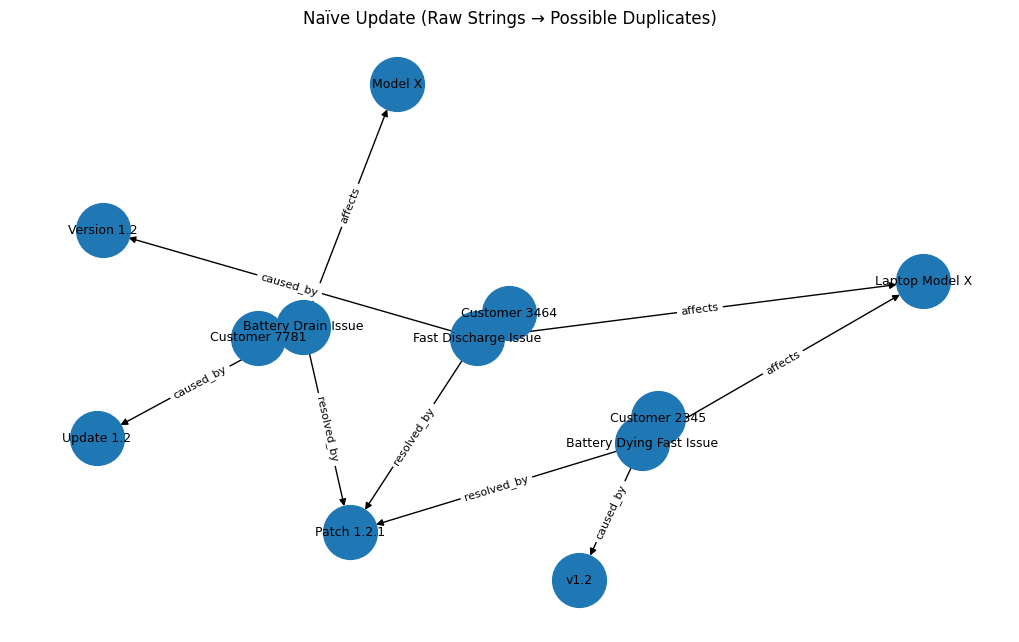

In [ ]:
draw_graph(G_naive, "Naïve Update (Raw Strings → Possible Duplicates)")


### 🧽 Canonicalization (Simple Dictionary)
Normalize entity names so variants map to one canonical identifier (reduces duplicates).


In [ ]:
def normalize_entity(name: str) -> str:
    """
    Simple demo canonicalization using a dictionary + a couple of lightweight helpers.

    Goal for this demo:
    - Collapse Issue variants (Battery Dying Fast Issue / Battery Drain Issue / Fast Discharge Issue) -> "Battery Drain"
    - Collapse product variants (Model X / Laptop Model X) -> "Laptop Model X"
    - Collapse version variants (v1.2 / Update 1.2 / Version 1.2) -> "Update v1.2"
    - Preserve customer IDs (Customer 2345 stays Customer 2345)
    - Keep Patch 1.2.1 consistent
    """
    s = re.sub(r"\s+", " ", str(name).strip())
    s_lower = s.lower()

    # ---- Preserve customer IDs in a stable format ----
    m = re.fullmatch(r"customer\s*([0-9]+)", s_lower)
    if m:
        return f"Customer {m.group(1)}"

    # ---- Canonicalize patches (resolution) ----
    # Handles "Patch 1.2.1" (and small format variants if they appear later)
    if re.search(r"\bpatch\s*(v)?\s*1\.2\.1\b", s_lower):
        return "Patch 1.2.1"

    # ---- Dictionary-based canonicalization (simple demo approach) ----
    # Note: This is intentionally simple. In production, you'd extend this with
    # embedding similarity or LLM-assisted entity resolution for unseen variants.
    synonyms = {
        # Causes / versions
        "v1.2": "Update v1.2",
        "update 1.2": "Update v1.2",
        "version 1.2": "Update v1.2",
        "update v1.2": "Update v1.2",

        # Products
        "model x": "Laptop Model X",
        "laptop model x": "Laptop Model X",

        # Issues (as extracted by the LLM)
        "battery dying fast issue": "Battery Drain",
        "battery drain issue": "Battery Drain",
        "fast discharge issue": "Battery Drain",
    }

    # Exact match first (covers your current outputs)
    if s_lower in synonyms:
        return synonyms[s_lower]

    # ---- Light fallback: handle “<issue wording> issue” even if new variants appear ----
    # Example: "Rapid Battery Drain Issue" -> treat as Battery Drain if it contains key terms.
    if s_lower.endswith(" issue"):
        if "battery" in s_lower and ("drain" in s_lower or "discharge" in s_lower or "dying fast" in s_lower):
            return "Battery Drain"

    # ---- Light fallback: handle new “version/update” formats ----
    if re.fullmatch(r"(v|version|update)\s*1\.2", s_lower):
        return "Update v1.2"

    # Final fallback: title-case for readability
    return s.title()


def canonicalize_triplets(triplets):
    return [(normalize_entity(s), r.strip(), normalize_entity(o)) for s, r, o in triplets]


all_triplets_canon = canonicalize_triplets(all_triplets_raw)
all_triplets_canon[:10]


[('Customer 2345', 'reports', 'Battery Drain'),
 ('Battery Drain', 'affects', 'Laptop Model X'),
 ('Battery Drain', 'caused_by', 'Update v1.2'),
 ('Battery Drain', 'resolved_by', 'Patch 1.2.1'),
 ('Customer 7781', 'reports', 'Battery Drain'),
 ('Battery Drain', 'affects', 'Laptop Model X'),
 ('Battery Drain', 'caused_by', 'Update v1.2'),
 ('Battery Drain', 'resolved_by', 'Patch 1.2.1'),
 ('Customer 3464', 'reports', 'Battery Drain'),
 ('Battery Drain', 'affects', 'Laptop Model X')]

### ✅ Graph Update (Canonicalized)
Rebuild the graph using canonicalized triplets so nodes get reused instead of duplicated.


In [ ]:
G_fixed = nx.DiGraph()
add_triplets(G_fixed, all_triplets_canon)

(G_naive.number_of_nodes(), G_fixed.number_of_nodes(),
 G_naive.number_of_edges(), G_fixed.number_of_edges())


(12, 7, 12, 6)

### 🎨 Visualize Fixed Graph
Compare structure after canonicalization to confirm node reuse and cleaner evidence paths.


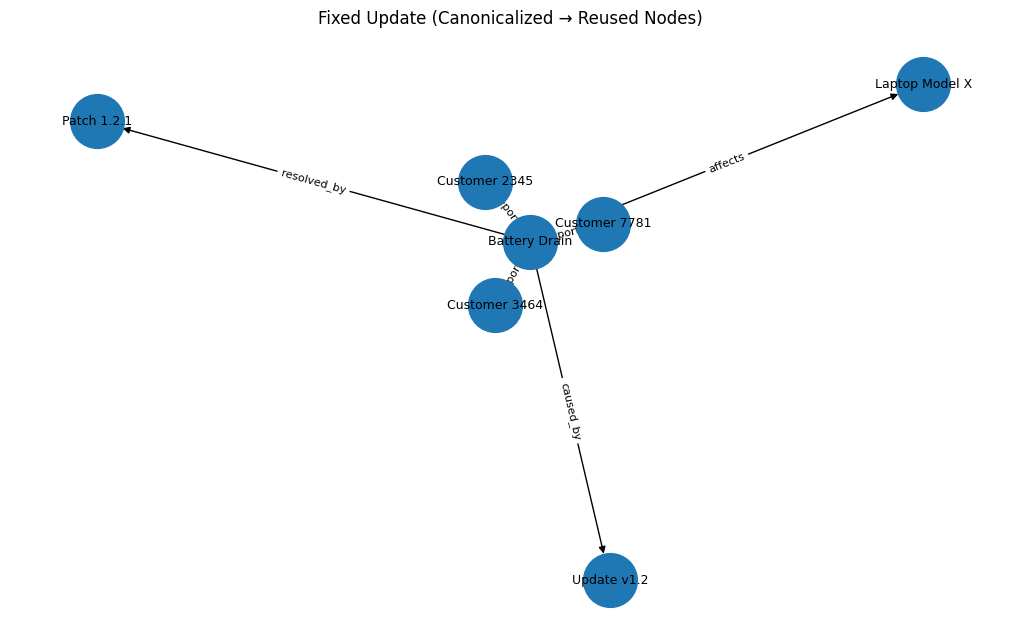

In [ ]:
draw_graph(G_fixed, "Fixed Update (Canonicalized → Reused Nodes)")


### 🔎 Verify Duplicate Collapse
Check that common variants (e.g., v1.2 vs update 1.2) collapse to a single canonical node.


In [ ]:
def nodes_like(G, pattern):
    pat = re.compile(pattern, re.IGNORECASE)
    return [n for n in G.nodes if pat.search(str(n))]

print("Naïve variants:", nodes_like(G_naive, r"(v1\.2|update 1\.2|update v1\.2)"))
print("Fixed variants:", nodes_like(G_fixed, r"(v1\.2|update 1\.2|update v1\.2)"))


Naïve variants: ['v1.2', 'Update 1.2']
Fixed variants: ['Update v1.2']
